# Bootstrapping with State Aggregation (n-step semi-gradient TD)

**Reproduces S&B Example 9.2 / Figure 9.2** (§9.3, p.204).

Same **1000-state random walk** as Figure 9.1, now learned by **bootstrapping**
methods instead of Monte Carlo.

- **Left:** the near-asymptotic value found by **semi-gradient TD(0)** with
  10-group aggregation. TD converges to the *TD fixed point* (where the projected
  Bellman error is zero), **not** the minimum of the value error -- so its
  staircase is *farther* from `v_π` than the MC staircase of Figure 9.1.
- **Right:** **n-step semi-gradient TD** with 20-group aggregation. With the
  groups quantitatively matched to the 19-state tabular walk (transitions of ~50
  states ≈ one group), the learning-rate curves come out **strikingly similar to
  the tabular n-step results of Figure 7.2**: intermediate `n` is best.

To match Figure 7.2 the performance measure here is an **unweighted** average RMS
error over all states and over the first 10 episodes (not the μ-weighted VE).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from rl.envs.random_walk import RandomWalk
from rl.dynamic_programming.policy_evaluation import policy_value
from rl.features.state_aggregation import StateAggregation
from rl.approximators.linear import LinearValue
from rl.prediction_approx.semi_gradient_td import semi_gradient_td
from rl.prediction_approx.n_step_semi_gradient_td import n_step_semi_gradient_td
from rl.utils.metrics import rmsve, uniform_weights

from random_walk_policy import uniform_jump_policy, policy_sampler
from random_walk_plots import plot_figure_9_2

## 1. Environment, policy, and ground truth

Identical setup to Figure 9.1: the ±100 uniform walk on the 1000-state chain, and
the exact `v_π` from solving the known model. `v_π` is the target both panels
measure error against.

In [2]:
env = RandomWalk(n_states=1000)                 # states 1..1000; terminals 0 and 1001; gamma = 1
pi = uniform_jump_policy(env, max_step=100)     # +/-100 uniform walk
sampler = policy_sampler(pi)
chain = [s for s in range(env.n_states) if s not in env.terminal_states()]

v_true = policy_value(env, pi)                  # exact v_pi
print(f'chain: {len(chain)} states, start: {env.START}')
print(f'v_true: v[1]={v_true[1]:.3f}, v[500]={v_true[500]:.3f}, v[1000]={v_true[1000]:.3f}')

chain: 1000 states, start: 500
v_true: v[1]=-0.922, v[500]=-0.001, v[1000]=0.922


## 2. Left panel — asymptotic semi-gradient TD(0)

Run TD(0) with the **same 10-group aggregation as Figure 9.1** for long enough to
reach its near-asymptotic solution, then read off the step function `v̂`. We
expect it to sit *inside* the true curve more than the MC version did — TD's fixed
point trades value-error for a self-consistent (bootstrapped) estimate.

In [3]:
vf_td = LinearValue(StateAggregation(chain, n_groups=10))
semi_gradient_td(env, sampler, vf_td, np.random.default_rng(0),
                 n_episodes=50_000, alpha=2e-4)
v_hat_td = vf_td.all_values(env.n_states)
print('TD(0) group values:', np.round(vf_td.w, 3))
print(f'ends: v_hat[1]={v_hat_td[1]:.3f} (true {v_true[1]:.3f}), '
      f'v_hat[1000]={v_hat_td[1000]:.3f} (true {v_true[1000]:.3f})')

TD(0) group values: [-0.7   -0.489 -0.314 -0.162 -0.024  0.092  0.218  0.356  0.515  0.708]
ends: v_hat[1]=-0.700 (true -0.922), v_hat[1000]=0.708 (true 0.922)


## 3. Right panel — n-step semi-gradient TD sweep

For each `n` and step size `α`, train a fresh **20-group** approximator for 10
episodes, recording the unweighted RMS error after each episode; average over the
first 10 episodes and over `N_RUNS` runs. Runs share seeds across `(n, α)` (common
random numbers), so the curves are compared on the same episodes.

Targets are bounded in [−1, 1] (reward is 0 except ±1 at termination), so even
α = 1 cannot diverge. **This is the slow cell (~10 min for 100 runs).**

In [4]:
ALPHAS = np.linspace(0.0, 1.0, 21)
N_VALUES = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
N_RUNS = 100
N_EPISODES = 10                                   # average RMS over the first 10 episodes

mu_uniform = uniform_weights(chain, env.n_states) # unweighted RMS (cf. Fig 7.2)

errors = np.zeros((len(N_VALUES), len(ALPHAS)))
for i, n in enumerate(N_VALUES):
    for j, alpha in enumerate(ALPHAS):
        run_errs = []
        for run in range(N_RUNS):
            vf = LinearValue(StateAggregation(chain, n_groups=20))
            rng = np.random.default_rng(seed=run)
            for _ in range(N_EPISODES):
                n_step_semi_gradient_td(env, sampler, vf, rng, 1, alpha, n=n)
                run_errs.append(rmsve(vf.all_values(env.n_states), v_true, mu_uniform))
        errors[i, j] = np.mean(run_errs)
    print(f'n={n:3d} done  (best RMS {errors[i].min():.3f} at alpha={ALPHAS[errors[i].argmin()]:.2f})')

n=  1 done  (best RMS 0.351 at alpha=0.80)
n=  2 done  (best RMS 0.304 at alpha=0.60)
n=  4 done  (best RMS 0.287 at alpha=0.40)
n=  8 done  (best RMS 0.297 at alpha=0.25)
n= 16 done  (best RMS 0.330 at alpha=0.15)
n= 32 done  (best RMS 0.378 at alpha=0.10)
n= 64 done  (best RMS 0.424 at alpha=0.05)
n=128 done  (best RMS 0.468 at alpha=0.05)
n=256 done  (best RMS 0.494 at alpha=0.05)
n=512 done  (best RMS 0.497 at alpha=0.05)


## 4. Figure 9.2

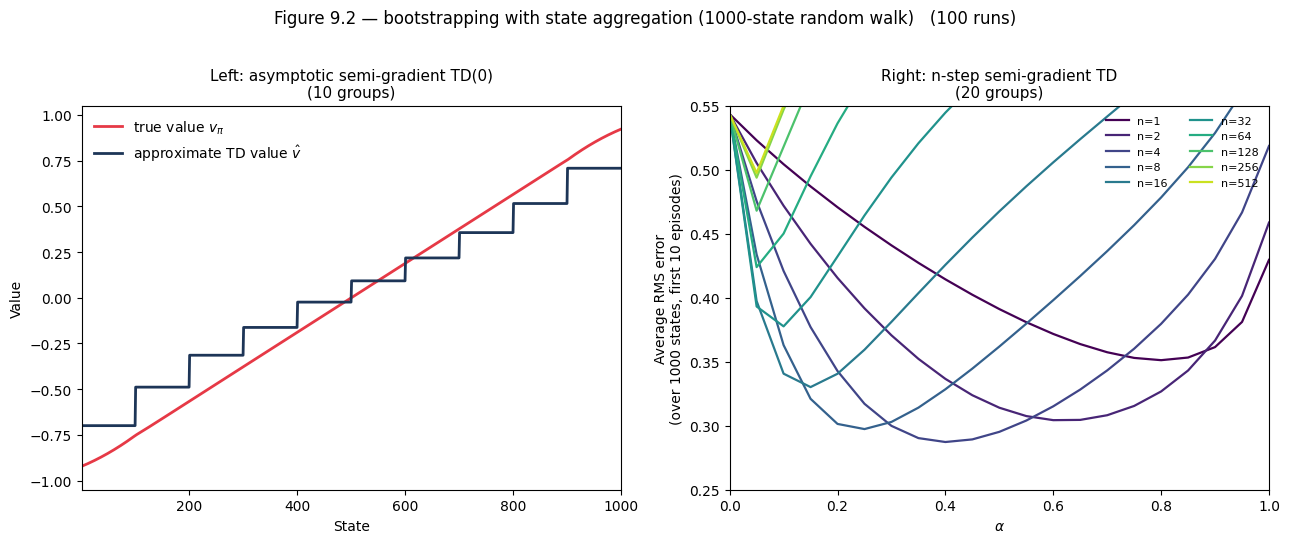

In [5]:
fig = plot_figure_9_2(chain, v_hat_td[chain], v_true[chain],
                      ALPHAS, N_VALUES, errors, n_runs=N_RUNS)
fig.savefig('figure_9_2.png', dpi=130, bbox_inches='tight')
plt.show()

**Reading it.**

*Left:* the TD staircase is flatter than MC's — its end steps fall well short of
±1. TD converges to the TD fixed point, whose value error is bounded by
`1/(1−γ)` times the best achievable; with bootstrapping that asymptote is worse
than Monte Carlo's (which directly minimizes VE).

*Right:* the U-shaped curves reproduce the tabular n-step picture (Fig 7.2). An
intermediate `n` (≈ 4) is best — short enough to bootstrap usefully, long enough
to propagate reward quickly. Small `n` learns slowly; large `n` approaches MC and
is noisier at these step sizes. State aggregation with matched group size behaves
almost exactly like the tabular representation.